# End-to-End CNN Image Classification Project

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from PIL import Image
from sklearn.metrics import classification_report
import shutil
from google.colab import drive
import zipfile

### Data Preparation

In [5]:
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/FruitinAmazon.zip'
extracted_base_path = '/content/fruit_dataset'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:

os.makedirs(extracted_base_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_base_path)

content_dirs = [d for d in os.listdir(extracted_base_path) if os.path.isdir(os.path.join(extracted_base_path, d))]
if len(content_dirs) == 1:
    data_dir = os.path.join(extracted_base_path, content_dirs[0])
elif len(content_dirs) > 1:
    data_dir = extracted_base_path
else:
    data_dir = extracted_base_path

print(f"Data directory set to: {data_dir}")

Data directory set to: /content/fruit_dataset/FruitinAmazon


### Task 1: Data Understanding and Visualization

In [7]:
class_names = sorted([name for name in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, name))])

plt.figure(figsize=(10, 5))
num_classes = len(class_names)

for i, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    if not files:
        continue
    random_image_name = random.choice(files)
    random_image_path = os.path.join(class_path, random_image_name)
    img = Image.open(random_image_path)

    plt.subplot(2, (num_classes + 1) // 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

### Task 1 (Part 2): Corrupted Image Detection

In [8]:
corrupted_images = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                corrupted_images.append(file_path)

if corrupted_images:
    for img_path in corrupted_images:
        os.remove(img_path)
        print(f"Removed corrupted image: {img_path}")
else:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


### Task 2: Loading and Preprocessing Image Data

In [9]:
image_size = (128, 128)
batch_size = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int'
)

class_names = train_ds.class_names
num_classes = len(class_names)

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 120 files belonging to 2 classes.
Using 96 files for training.
Found 120 files belonging to 2 classes.
Using 24 files for validation.


### Task 3: Implement a CNN

In [10]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(image_size[0], image_size[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Task 4: Compile the Model

In [11]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

### Task 5: Train the Model

In [12]:
epochs = 250

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint_filepath = 'best_model.h5'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint_callback]
)

Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.5356 - loss: 1.0494

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6458 - loss: 0.9024 - val_accuracy: 0.9167 - val_loss: 0.6609
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 335ms/step - accuracy: 0.7083 - loss: 0.6276 - val_accuracy: 0.9167 - val_loss: 0.3995
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 339ms/step - accuracy: 0.7083 - loss: 0.5782 - val_accuracy: 0.9167 - val_loss: 0.4480
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 346ms/step - accuracy: 0.7292 - loss: 0.5707 - val_accuracy: 0.9167 - val_loss: 0.4590
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 497ms/step - accuracy: 0.7083 - loss: 0.4928 - val_accuracy: 0.9167 - val_loss: 0.4678
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 567ms/step - accuracy: 0.8854 - loss: 0.3789 - val_accuracy: 0.9167 - val_loss: 0.3397
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 337ms/step - accuracy: 0.8125 - loss: 0.4160 - val_accuracy: 0.7917 - val_loss: 0.5482
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - accuracy: 0.8750 - loss: 0.2862 - val_accuracy: 0.9167 - val_loss: 0.363

### Visualization

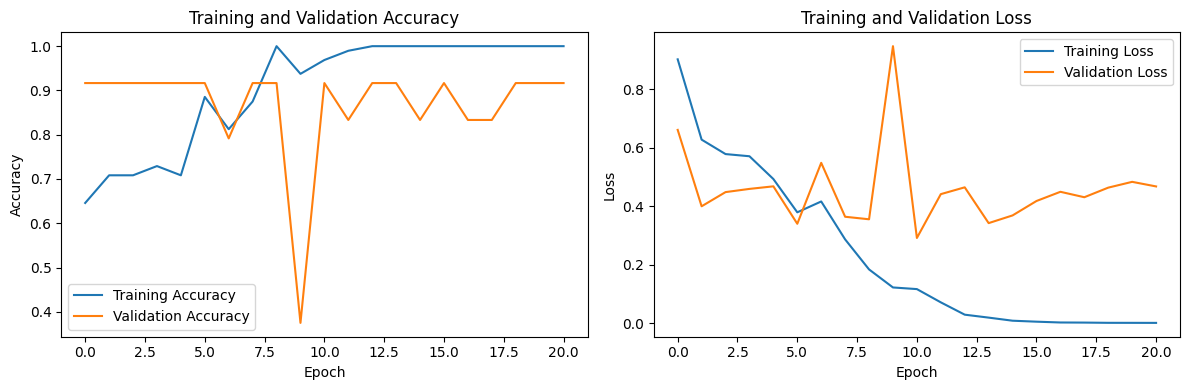

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Task 6: Evaluate the Model

In [14]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9167 - loss: 0.2911
Validation Loss: 0.2911
Validation Accuracy: 0.9167


### Task 7: Save and Load the Model

In [15]:
model.save('final_image_classifier.h5')

loaded_model = tf.keras.models.load_model('final_image_classifier.h5')

loaded_loss, loaded_accuracy = loaded_model.evaluate(val_ds)
print(f"Loaded Model Validation Loss: {loaded_loss:.4f}")
print(f"Loaded Model Validation Accuracy: {loaded_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9167 - loss: 0.2911 
Loaded Model Validation Loss: 0.2911
Loaded Model Validation Accuracy: 0.9167


### Task 8: Predictions and Classification Report

In [16]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
              precision    recall  f1-score   support

        test       0.00      0.00      0.00         2
       train       0.92      1.00      0.96        22

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# End-to-End CNN Image Classification Project

In [18]:
import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from PIL import Image
from sklearn.metrics import classification_report
import shutil
from google.colab import drive
import zipfile

### Data Preparation

In [19]:

os.makedirs(extracted_base_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_base_path)

content_dirs = [d for d in os.listdir(extracted_base_path) if os.path.isdir(os.path.join(extracted_base_path, d))]
if len(content_dirs) == 1:
    data_dir = os.path.join(extracted_base_path, content_dirs[0])
    print(f"Assuming data is in a single subdirectory: {data_dir}")
elif len(content_dirs) > 1:
    data_dir = extracted_base_path
    print(f"Assuming class folders are directly in: {data_dir}")
else:
    print("Could not determine data directory structure after extraction. Please verify the zip content.")
    data_dir = extracted_base_path

print(f"Data directory set to: {data_dir}")

Assuming data is in a single subdirectory: /content/fruit_dataset/FruitinAmazon
Data directory set to: /content/fruit_dataset/FruitinAmazon


### Task 1: Data Understanding and Visualization

In [20]:
class_names = sorted([name for name in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, name))])

plt.figure(figsize=(10, 5))
num_classes = len(class_names)

for i, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    if not files:
        continue
    random_image_name = random.choice(files)
    random_image_path = os.path.join(class_path, random_image_name)
    img = Image.open(random_image_path)

    plt.subplot(2, (num_classes + 1) // 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

### Task 1 (Part 2): Corrupted Image Detection

In [21]:
corrupted_images = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                corrupted_images.append(file_path)

if corrupted_images:
    for img_path in corrupted_images:
        os.remove(img_path)
        print(f"Removed corrupted image: {img_path}")
else:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


### Task 2: Data Loading and Preprocessing

In [22]:
image_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int'
)

class_names = train_ds.class_names
num_classes = len(class_names)

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 120 files belonging to 2 classes.
Using 96 files for training.
Found 120 files belonging to 2 classes.
Using 24 files for validation.


### Task 3: CNN Model Implementation

In [23]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(image_size[0], image_size[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Task 4: Compile Model

In [24]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

### Task 5: Train Model

In [25]:
epochs = 250

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint_filepath = 'best_model.h5'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint_callback]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.5642 - loss: 0.8792

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 952ms/step - accuracy: 0.6458 - loss: 1.0617 - val_accuracy: 0.0833 - val_loss: 0.9732
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.3819 - loss: 0.7869

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 726ms/step - accuracy: 0.5208 - loss: 0.7088 - val_accuracy: 0.9167 - val_loss: 0.3531
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 669ms/step - accuracy: 0.7083 - loss: 0.6277 - val_accuracy: 0.9167 - val_loss: 0.3626
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 739ms/step - accuracy: 0.7083 - loss: 0.5845 - val_accuracy: 0.9167 - val_loss: 0.5063
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 642ms/step - accuracy: 0.7083 - loss: 0.5586 - val_accuracy: 0.9167 - val_loss: 0.3929
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7083 - loss: 0.5507 - val_accuracy: 0.9167 - val_loss: 0.4534
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 814ms/step - accuracy: 0.7396 - loss: 0.4835 - val_accuracy: 0.9167 - val_loss: 0.3829
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 661ms/step - accuracy: 0.7396 - loss: 0.4402 - val_accuracy: 0.9167 - val_loss: 0.3861
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 662ms/step - accuracy: 0.9062 - loss: 0.3797 - val_accuracy: 0.9167 - val_loss: 0.3927

### Visualization

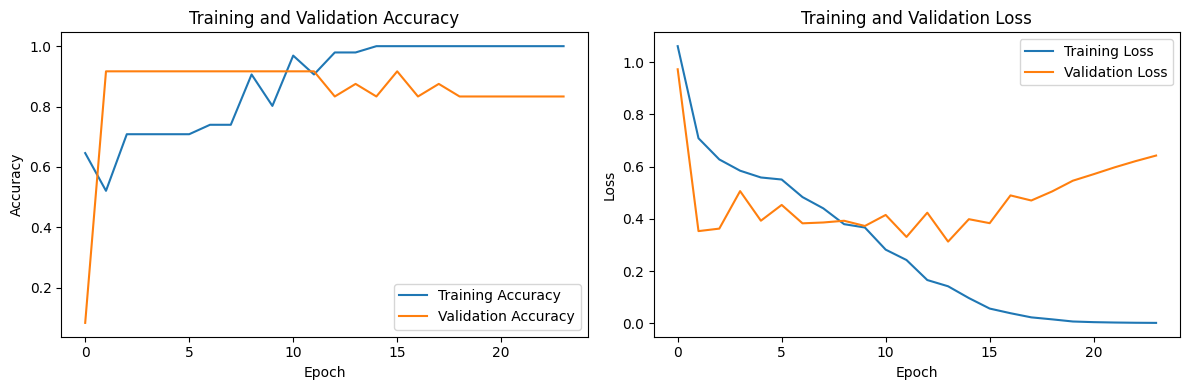

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Task 6: Evaluate Model

In [27]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8750 - loss: 0.3128
Validation Loss: 0.3128
Validation Accuracy: 0.8750


### Task 7: Save and Load Model

In [28]:
model.save('final_image_classifier.h5')
print("Model saved as final_image_classifier.h5")

loaded_model = tf.keras.models.load_model('final_image_classifier.h5')
print("Model loaded from final_image_classifier.h5")

loaded_loss, loaded_accuracy = loaded_model.evaluate(val_ds)
print(f"Loaded Model Validation Loss: {loaded_loss:.4f}")
print(f"Loaded Model Validation Accuracy: {loaded_accuracy:.4f}")

Model saved as final_image_classifier.h5
Model loaded from final_image_classifier.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.8750 - loss: 0.3128
Loaded Model Validation Loss: 0.3128
Loaded Model Validation Accuracy: 0.8750


### Task 8: Predictions and Classification Report

In [29]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)


report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step

Classification Report:
              precision    recall  f1-score   support

        test       0.00      0.00      0.00         2
       train       0.91      0.95      0.93        22

    accuracy                           0.88        24
   macro avg       0.46      0.48      0.47        24
weighted avg       0.84      0.88      0.86        24

